<a href="https://colab.research.google.com/github/SrushtiSunkad630/MACHINE-LEARNING-LAB/blob/main/1BM23CS341_Lab_9_Adaboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

n_estimators = 10
Accuracy: 0.8182004299314157
n_estimators = 10, Accuracy = 0.8182
n_estimators = 20, Accuracy = 0.8244
n_estimators = 50, Accuracy = 0.8327
n_estimators = 100, Accuracy = 0.8328
n_estimators = 150, Accuracy = 0.8329
n_estimators = 200, Accuracy = 0.8332

Best Accuracy: 0.8332480294810114
Best n_estimators: 200


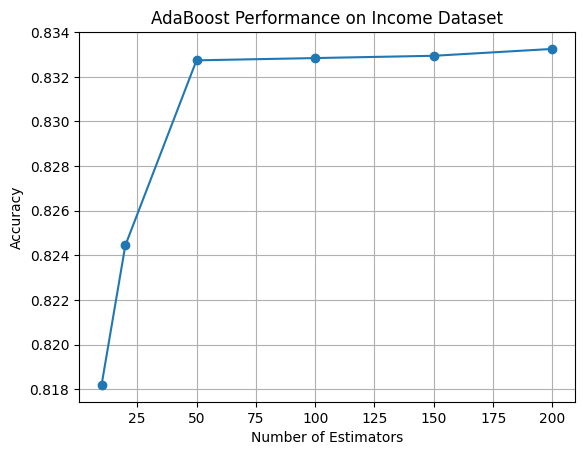

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = pd.read_csv("income.csv")

# -------------------------------
# Data Preprocessing
# -------------------------------

# Handle missing values (if any)
data = data.dropna()

# Encode categorical columns
for col in data.columns:
    if data[col].dtype == 'object':
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])

# Features and target (assume last column is target)
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 1. AdaBoost with n_estimators = 10
# -------------------------------
ada_default = AdaBoostClassifier(n_estimators=10, random_state=42)
ada_default.fit(X_train, y_train)

y_pred_default = ada_default.predict(X_test)

print("n_estimators = 10")
print("Accuracy:", accuracy_score(y_test, y_pred_default))


# -------------------------------
# 2. Hyperparameter Tuning
# -------------------------------
estimator_values = [10, 20, 50, 100, 150, 200]
scores = []

for n in estimator_values:
    ada = AdaBoostClassifier(n_estimators=n, random_state=42)
    ada.fit(X_train, y_train)

    y_pred = ada.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    scores.append(acc)

    print(f"n_estimators = {n}, Accuracy = {acc:.4f}")

# Best result
best_score = max(scores)
best_estimators = estimator_values[scores.index(best_score)]

print("\nBest Accuracy:", best_score)
print("Best n_estimators:", best_estimators)


# -------------------------------
# 3. Plot Results
# -------------------------------
plt.plot(estimator_values, scores, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("AdaBoost Performance on Income Dataset")
plt.grid()
plt.show()